In [2]:
# Cell 0 — make repo root importable
from pathlib import Path
import sys

# notebook is in: <repo>/notebooks
repo_root = Path.cwd().parent           # go up to repo root
utils_dir = repo_root / "utils"

assert utils_dir.exists(), f"'utils' folder not found at: {utils_dir}"

# Put repo root at the FRONT of sys.path so `import utils...` works
sys.path.insert(0, str(repo_root))
print("Repo root added to sys.path:", repo_root)

Repo root added to sys.path: C:\Users\John Koh\Desktop\Australia\University\2025 Sem 2\CITS 4403\Project


In [3]:
# Cell 1 — imports
from pathlib import Path
from utils.io import find_runs, load_run, load_runs
from utils.metrics import summarise, equilibrium_checks
from utils.plotting import (
    plot_macro, plot_shares, plot_reach_bar,
    plot_multi_run_overlay, plot_snapshots
)


In [4]:
runs_dir = Path("../data/johnkoh/runs")  # .. because notebook lives in notebooks/
paths = find_runs(runs_dir)
assert paths, "No runs found. Run: python -m johnkoh.model.run from repo root."
latest = paths[-1]
d = load_run(latest)
print(f"Loaded: {latest}")
print(summarise(d))
print(equilibrium_checks(d))

Loaded: ..\data\johnkoh\runs\CA_run_20251011-193041.json
{'seed_used': 573929556, 'peak_fake': 152, 'peak_real': 451, 't_peak_fake': 51, 't_peak_real': 58, 'reach_fake': 44.48, 'reach_real': 82.28, 'cum_shares_fake': 5003, 'cum_shares_real': 11375}
{'t_eq_fake': None, 't_eq_real': None}


<Axes: title={'center': 'New Shares per Step (Flow Dynamics)'}, xlabel='Time step', ylabel='New shares'>

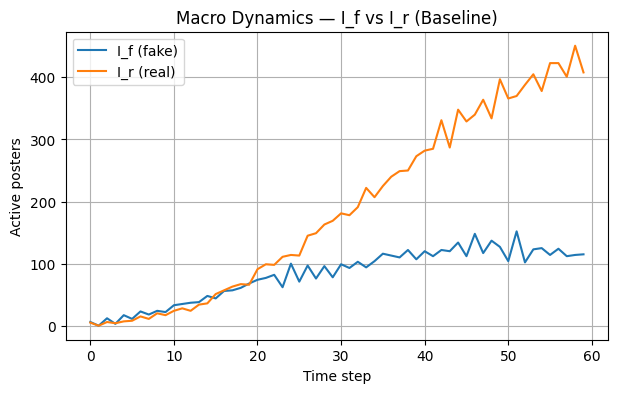

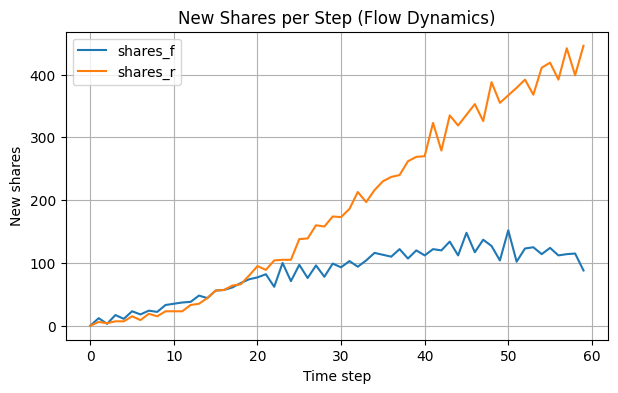

In [5]:
plot_macro(d, title="Macro Dynamics — I_f vs I_r (Baseline)")
plot_shares(d, title="New Shares per Step (Flow Dynamics)")

array([<Axes: title={'center': 't0'}>, <Axes: title={'center': 't15'}>,
       <Axes: title={'center': 't30'}>, <Axes: title={'center': 't59'}>],
      dtype=object)

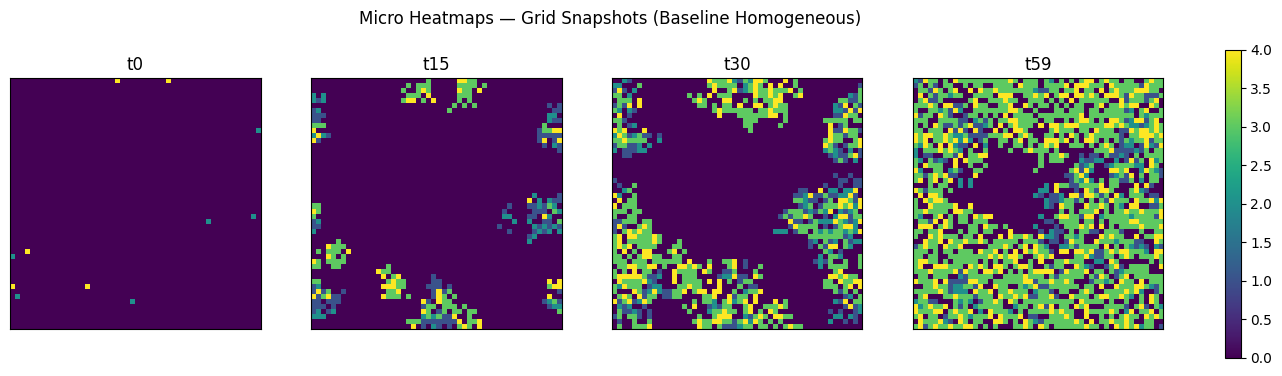

In [6]:
# Heatmaps of grid snapshots (micro). Requires 'grid_snapshots' in your JSON.
plot_snapshots(d, title="Micro Heatmaps — Grid Snapshots (Baseline Homogeneous)")

<Axes: title={'center': 'Reach Comparison — Fake vs Real Across Runs'}, ylabel='Reach (%)'>

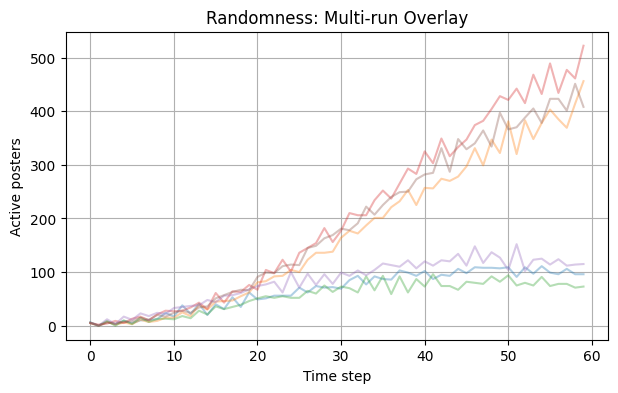

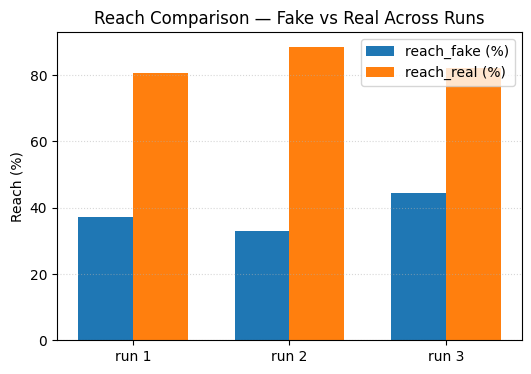

In [9]:
# Run a couple more times first in a terminal:
# python -m johnkoh.model.run  (repeat 2–3x)

some = load_runs(find_runs(runs_dir)[-3:])
plot_multi_run_overlay(some, title="Randomness: Multi-run Overlay")
plot_reach_bar(some, title="Reach Comparison — Fake vs Real Across Runs")

In [8]:
import matplotlib.pyplot as plt
figdir = Path("../data/johnkoh/figures")
figdir.mkdir(parents=True, exist_ok=True)
plt.savefig(figdir / "baseline_macro_micro.png", dpi=200, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>